In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Facebook_Marketplace_data.csv')
df

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7045,7046,photo,9/24/2016 2:58,89,0,0,89,0,0,0,0,0,NaN,NaN,NaN,NaN
7046,7047,photo,9/23/2016 11:19,16,0,0,14,1,0,1,0,0,NaN,NaN,NaN,NaN
7047,7048,photo,9/21/2016 23:03,2,0,0,1,1,0,0,0,0,NaN,NaN,NaN,NaN
7048,7049,photo,9/20/2016 0:43,351,12,22,349,2,0,0,0,0,NaN,NaN,NaN,NaN


# Ques 1. How does the time of upload (`status_published`)  affects the `num_reaction`?

In [2]:
# As the timestamp in the csv file is in the format of string/object, so i have converted it to date time format
df['status_published'] = pd.to_datetime(df['status_published'])
df['status_published']

,status_published
0,2018-04-22 06:00:00
1,2018-04-21 22:45:00
2,2018-04-21 06:17:00
3,2018-04-21 02:29:00
4,2018-04-18 03:22:00
...,...
7045,2016-09-24 02:58:00
7046,2016-09-23 11:19:00
7047,2016-09-21 23:03:00
7048,2016-09-20 00:43:00


Here I have extracted time features as the status_published can affect the num_reactions in factors

In [3]:
# Hourwise (0–23)
df['upload_hour'] = df['status_published'].dt.hour

# Daywise (Monday–Sunday)
df['upload_day'] = df['status_published'].dt.day_name()

# Yearly (2012 - 18)
df['upload_year'] = df['status_published'].dt.year

## Hourly Reaction Analysis

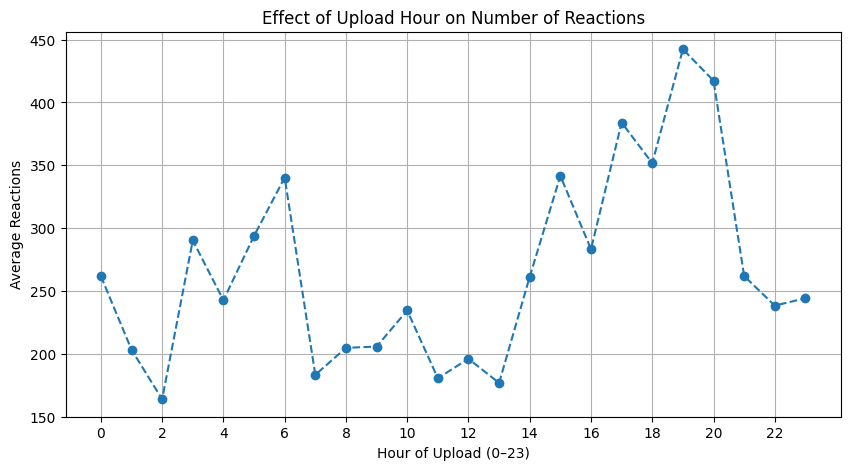

In [4]:
hourly_avg = df.groupby('upload_hour')['num_reactions'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_avg.index, hourly_avg.values, linestyle='--', marker='o')
plt.xticks(np.arange(0, 24, 2))
plt.xlabel("Hour of Upload (0–23)")
plt.ylabel("Average Reactions")
plt.title("Effect of Upload Hour on Number of Reactions")
plt.grid()
plt.show()

## Daily Reaction Analysis

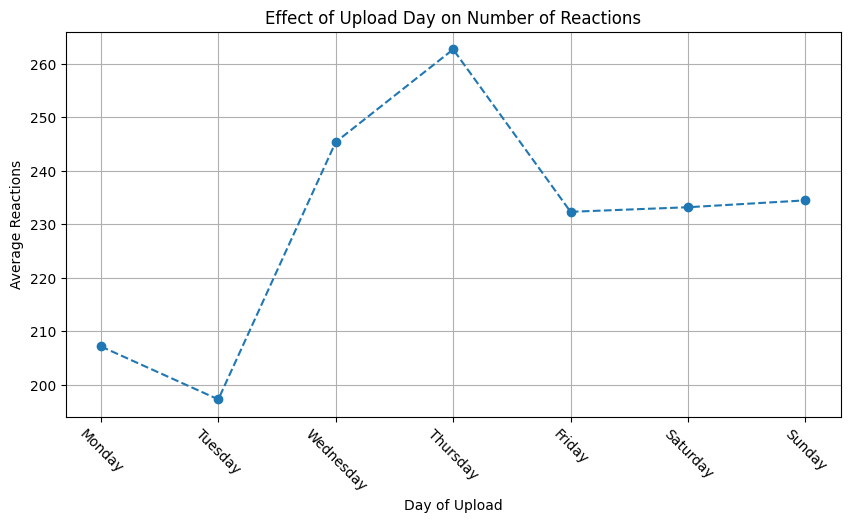

In [5]:
day_avg = df.groupby('upload_day')['num_reactions'].mean()

# Correct weekday order
day_avg = day_avg.reindex([
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"])

plt.figure(figsize=(10,5))
plt.plot(day_avg.index, day_avg.values, linestyle='--', marker='o')
plt.xticks(rotation=-45)
plt.xlabel("Day of Upload")
plt.ylabel("Average Reactions")
plt.title("Effect of Upload Day on Number of Reactions")
plt.grid()
plt.show()

## Yearly Reaction Analysis

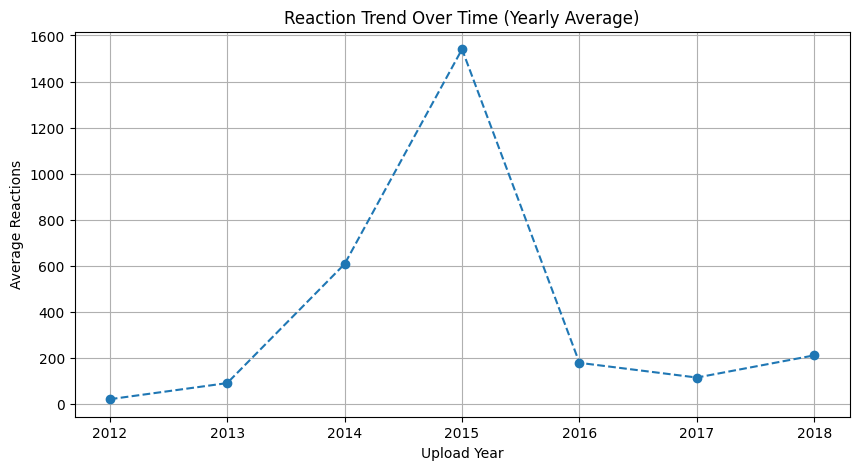

In [6]:
yearly_avg = df.groupby('upload_year')['num_reactions'].mean()

plt.figure(figsize=(10,5))
plt.plot(yearly_avg.index, yearly_avg.values, linestyle='--', marker='o')
plt.xlabel("Upload Year")
plt.ylabel("Average Reactions")
plt.title("Reaction Trend Over Time (Yearly Average)")
plt.xticks(yearly_avg.index)
plt.grid()
plt.show()

# Ques 2. Is there a correlation between the number of reactions (num_reactions) and other engagement metrics such as comments (num_comments) and shares (num_shares)? If so, what is the strength and direction of this correlation?

Combining all 3 columns in one variable

In [7]:
# Select engagement metrics
engagement_data = df[['num_reactions', 'num_comments', 'num_shares']]

Calculating correlation by **pearson correlation** method

In [8]:
# Compute correlation matrix
correlation_matrix = engagement_data.corr(method='pearson')

In [9]:
# Function to determine the strength and direction of the correlation
def interpret_corr(value):

    # Direction
    if value > 0:
        direction = "Positive"
    elif value < 0:
        direction = "Negative"
    else:
        direction = "No Correlation"

    abs_val = abs(value)       # Strength (Absolute Value)

    if abs_val < 0.3:
        strength = "Weak"
    elif abs_val < 0.6:
        strength = "Moderate"
    else:
        strength = "Strong"

    return strength, direction

## **CORRELATION MATRIX**

In [10]:
print("Correlation Matrix:\n")
print(correlation_matrix)

Correlation Matrix:

               num_reactions  num_comments  num_shares
num_reactions       1.000000      0.150843    0.250723
num_comments        0.150843      1.000000    0.640637
num_shares          0.250723      0.640637    1.000000


## Correlation Strength and Direction

### Interpretation of Correlation Strength and Direction

Positive direction → Metrics increase together

Strong correlation → Engagement values are closely related

Moderate correlation → Related but not perfectly

In [11]:
pairs = [
    ("num_reactions", "num_comments"),
    ("num_reactions", "num_shares"),
    ("num_comments", "num_shares")
]

print("Correlation Strength and Direction:\n")

for x, y in pairs:
    corr_value = correlation_matrix.loc[x, y]
    strength, direction = interpret_corr(corr_value)

    print(f"{x} vs {y}:")
    print(f"   Correlation Value = {corr_value:.2f}")
    print(f"   Strength = {strength}")
    print(f"   Direction = {direction}\n")

Correlation Strength and Direction:

num_reactions vs num_comments:
   Correlation Value = 0.15
   Strength = Weak
   Direction = Positive

num_reactions vs num_shares:
   Correlation Value = 0.25
   Strength = Weak
   Direction = Positive

num_comments vs num_shares:
   Correlation Value = 0.64
   Strength = Strong
   Direction = Positive



# Ques 3.	Use the columns status_type, num_reactions, num_comments, num_shares, num_likes, num_loves, num_wows, num_hahas, num_sads, and num_angrys to train a K-Means clustering model on the Facebook Live Sellers dataset.


In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [13]:
# Column Selection
columns = [
    'status_type', 'num_reactions', 'num_comments', 'num_shares',
    'num_likes', 'num_loves', 'num_wows', 'num_hahas',
    'num_sads', 'num_angrys'
]

data = df[columns]

OneHot Encoding

In [14]:
# Categorical column
categorical_col = ['status_type']

# Numerical columns
numerical_cols = [
    'num_reactions', 'num_comments', 'num_shares',
    'num_likes', 'num_loves', 'num_wows', 'num_hahas',
    'num_sads', 'num_angrys'
]

# OneHotEncoder for categorical column only
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), categorical_col)], remainder='passthrough')

# Transform dataset
encoded_data = ct.fit_transform(data)

print("✅ OneHotEncoder Applied Successfully!")

✅ OneHotEncoder Applied Successfully!


In [15]:
# Feature Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(encoded_data)

print("✅ Data Standardized Successfully!")

✅ Data Standardized Successfully!


As it is not mentioned to use elbow methos to train the K-Means model, I have not used it and considered 3 as the optimal value of K.

In [16]:
kmeans = KMeans(n_clusters = 3, random_state = 42)
clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels to original dataset
df['cluster'] = clusters

print("✅ K-Means Model Trained Successfully!")

✅ K-Means Model Trained Successfully!


In [17]:
df[['status_type', 'num_reactions', 'cluster']]

,status_type,num_reactions,cluster
0,video,529,1
1,photo,150,0
2,video,227,1
3,photo,111,0
4,photo,213,0
...,...,...,...
7045,photo,89,0
7046,photo,16,0
7047,photo,2,0
7048,photo,351,0


# Ques 4.	Use the elbow method to find the optimum number of clusters.

In [18]:
# As no columns are mentioned, I have used the same columns that of Ques 3.

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    # Fit model
    kmeans.fit(scaled_data)
    # Comp[ute WCSS values
    wcss.append(kmeans.inertia_)

## Elbow Method Graph

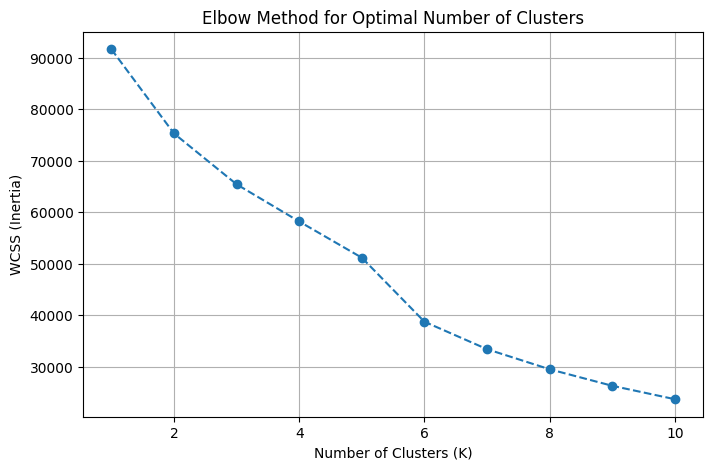

In [19]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, linestyle="--", marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.grid()

plt.show()

In [20]:
# Final KMeans Model with Optimal K = 6
kmeans_final = KMeans(n_clusters=6, init='k-means++', random_state=42)

y_kmeans = kmeans_final.fit_predict(scaled_data)

# Add clusters to dataframe
df["Cluster"] = y_kmeans

print("✅ Final KMeans Model Trained with K = 6")
df[['status_type', 'num_reactions', 'Cluster']]


✅ Final KMeans Model Trained with K = 6


,status_type,num_reactions,Cluster
0,video,529,5
1,photo,150,0
2,video,227,5
3,photo,111,0
4,photo,213,0
...,...,...,...
7045,photo,89,0
7046,photo,16,0
7047,photo,2,0
7048,photo,351,0


# Ques 5.	What is the count of different types of posts in the dataset?

In [21]:
post_count = df['status_type'].value_counts()

print("✅ Count of Different Types of Posts:\n")
post_count

✅ Count of Different Types of Posts:



,count
status_type,
photo,4288
video,2334
status,365
link,63


# Ques 6.	What is the average value of num_reaction, num_comments, num_shares for each post type?

In [22]:
b = df.groupby('status_type')[['num_reactions', 'num_comments', 'num_shares']].mean()
b

,num_reactions,num_comments,num_shares
status_type,,,
link,370.142857,5.698413,4.396825
photo,181.290345,15.993470,2.553871
status,438.783562,36.238356,2.558904
video,283.409597,642.478149,115.679949
